📂  Loading MIT-BIH Arrhythmia Dataset …
   Classes found : 5
   Train samples : 10,000
   Test  samples : 2,000
🔧  Training Random Forest …
   ✅  Accuracy: 96.00%
🔧  Training XGBoost …
   ✅  Accuracy: 96.75%
🔧  Training Ensemble …
   ✅  Accuracy: 96.60%

🏆  Best Model : XGBoost  (96.75%)

  CARDIOVASCULAR DISEASE DETECTION — CLINICAL PREVIEW
  Model: XGBoost

  Patient 01
  Actual Condition      : Healthy  🟢 Low Risk
  Predicted Condition   : Healthy  🟢 Low Risk
  Clinical Advice       : No immediate action needed. Routine checkup recommended.
  Result                : ✅ Correct
  ────────────────────────────────────────────────────────────────────

  Patient 02
  Actual Condition      : Healthy  🟢 Low Risk
  Predicted Condition   : Healthy  🟢 Low Risk
  Clinical Advice       : No immediate action needed. Routine checkup recommended.
  Result                : ✅ Correct
  ────────────────────────────────────────────────────────────────────

  Patient 03
  Actual Condition      : Healthy

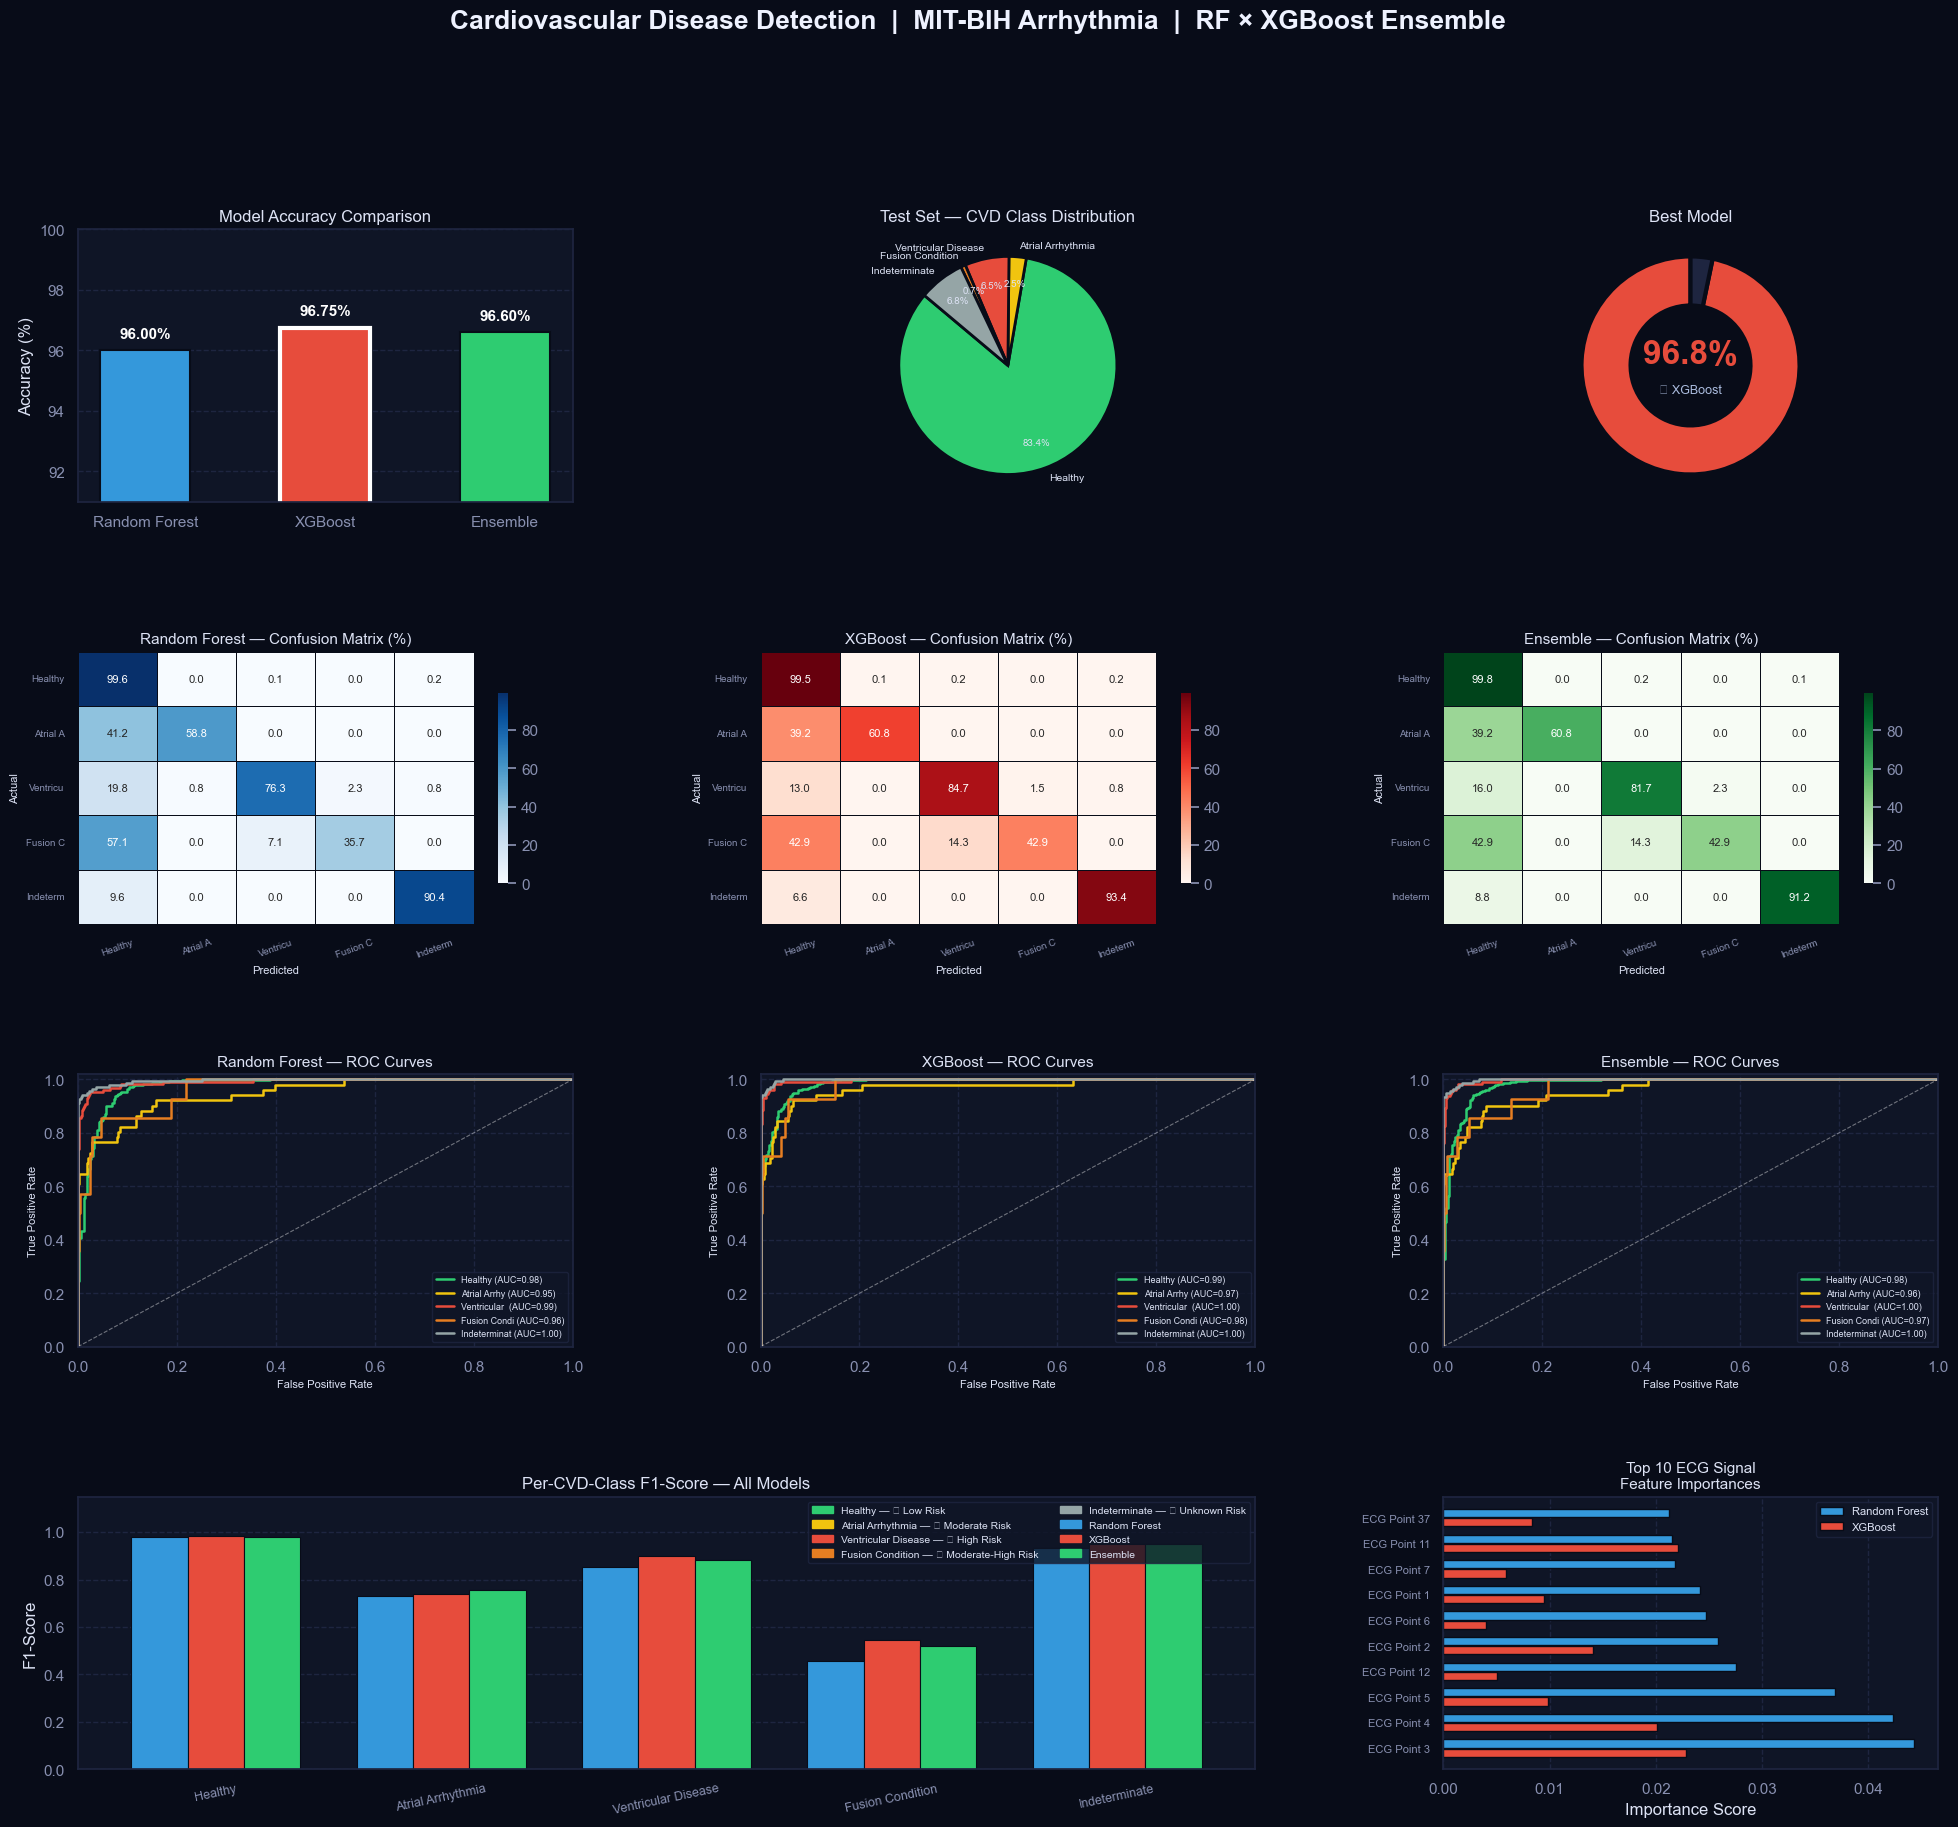


📊  Dashboard saved → cvd_detection_dashboard.png


In [1]:
"""
╔══════════════════════════════════════════════════════════════════════╗
║       Cardiovascular Disease Detection — RF × XGBoost Ensemble       ║
║                  Using MIT-BIH Arrhythmia Dataset                    ║
╚══════════════════════════════════════════════════════════════════════╝

  Beat Classes → Cardiovascular Risk Mapping:
  ┌─────────────────────────────────┬──────────────────────────────────┐
  │ MIT-BIH Label                   │ Cardiovascular Interpretation    │
  ├─────────────────────────────────┼──────────────────────────────────┤
  │ 0 — Normal Beat                 │ Healthy — No Disease             │
  │ 1 — Supraventricular Premature  │ Atrial Arrhythmia (Moderate)     │
  │ 2 — Ventricular Premature       │ Ventricular Disease (High Risk)  │
  │ 3 — Fusion Beat                 │ Mixed Cardiac Condition          │
  │ 4 — Unknown / Unclassified      │ Indeterminate — Monitor Needed   │
  └─────────────────────────────────┴──────────────────────────────────┘
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────
#  CONFIGURATION
# ─────────────────────────────────────────────────────────────
TRAIN_PATH    = "mitbih_train.csv"
TEST_PATH     = "mitbih_test.csv"
TRAIN_SAMPLES = 10000
TEST_SAMPLES  = 2000
RANDOM_STATE  = 42
PREVIEW_CASES = 10

# Cardiovascular disease labels
CVD_LABEL_MAP = {
    0: "Healthy",
    1: "Atrial Arrhythmia",
    2: "Ventricular Disease",
    3: "Fusion Condition",
    4: "Indeterminate",
}

# Risk levels for each class
RISK_MAP = {
    0: "🟢 Low Risk",
    1: "🟡 Moderate Risk",
    2: "🔴 High Risk",
    3: "🟠 Moderate-High Risk",
    4: "⚪ Unknown Risk",
}

# Clinical advice per class
CLINICAL_MAP = {
    0: "No immediate action needed. Routine checkup recommended.",
    1: "Monitor for atrial fibrillation. Refer to cardiologist if recurrent.",
    2: "Urgent cardiology referral. Risk of sudden cardiac arrest.",
    3: "Requires detailed ECG analysis. Possible multi-focal origin.",
    4: "Further diagnostic tests needed. Do not ignore symptoms.",
}

PALETTE = {
    0: "#2ecc71",
    1: "#f1c40f",
    2: "#e74c3c",
    3: "#e67e22",
    4: "#95a5a6",
}

MODEL_COLORS = {
    "Random Forest": "#3498db",
    "XGBoost":       "#e74c3c",
    "Ensemble":      "#2ecc71",
}

# ─────────────────────────────────────────────────────────────
#  1. DATA LOADING
# ─────────────────────────────────────────────────────────────
print("📂  Loading MIT-BIH Arrhythmia Dataset …")
train_data = pd.read_csv(TRAIN_PATH, header=None).sample(n=TRAIN_SAMPLES, random_state=RANDOM_STATE)
test_data  = pd.read_csv(TEST_PATH,  header=None).sample(n=TEST_SAMPLES,  random_state=RANDOM_STATE)

X_train, y_train = train_data.iloc[:, :-1], train_data.iloc[:, -1].astype(int)
X_test,  y_test  = test_data.iloc[:,  :-1], test_data.iloc[:,  -1].astype(int)

n_classes = len(np.unique(y_train))
print(f"   Classes found : {n_classes}")
print(f"   Train samples : {len(X_train):,}")
print(f"   Test  samples : {len(X_test):,}")

# ─────────────────────────────────────────────────────────────
#  2. MODEL SETUP
# ─────────────────────────────────────────────────────────────
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=RANDOM_STATE,
    verbosity=0,
)

ensemble_model = VotingClassifier(
    estimators=[("rf", rf_model), ("xgb", xgb_model)],
    voting="soft",
    n_jobs=-1,
)

models = {
    "Random Forest": rf_model,
    "XGBoost":       xgb_model,
    "Ensemble":      ensemble_model,
}

# ─────────────────────────────────────────────────────────────
#  3. TRAIN & EVALUATE
# ─────────────────────────────────────────────────────────────
results   = {}
classes   = sorted(CVD_LABEL_MAP.keys())
y_bin     = label_binarize(y_test, classes=classes)

for name, model in models.items():
    print(f"🔧  Training {name} …")
    model.fit(X_train, y_train)
    y_pred   = model.predict(X_test)
    y_proba  = model.predict_proba(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    cm       = confusion_matrix(y_test, y_pred, labels=classes)
    report   = classification_report(
        y_test, y_pred,
        labels=classes,
        target_names=[CVD_LABEL_MAP[k] for k in classes],
        output_dict=True, zero_division=0,
    )

    # ROC per class
    fpr_dict, tpr_dict, roc_auc_dict = {}, {}, {}
    for i, cls in enumerate(classes):
        if y_bin[:, i].sum() > 0:
            fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba[:, i])
            fpr_dict[cls] = fpr
            tpr_dict[cls] = tpr
            roc_auc_dict[cls] = auc(fpr, tpr)

    results[name] = {
        "model":    model,
        "y_pred":   y_pred,
        "y_proba":  y_proba,
        "accuracy": accuracy,
        "cm":       cm,
        "report":   pd.DataFrame(report).T,
        "fpr":      fpr_dict,
        "tpr":      tpr_dict,
        "roc_auc":  roc_auc_dict,
    }
    print(f"   ✅  Accuracy: {accuracy*100:.2f}%")

best_name = max(results, key=lambda k: results[k]["accuracy"])
best_pred = results[best_name]["y_pred"]
print(f"\n🏆  Best Model : {best_name}  ({results[best_name]['accuracy']*100:.2f}%)\n")

# ─────────────────────────────────────────────────────────────
#  4. CONSOLE — Clinical Report for First N Cases
# ─────────────────────────────────────────────────────────────
print("=" * 72)
print("  CARDIOVASCULAR DISEASE DETECTION — CLINICAL PREVIEW")
print(f"  Model: {best_name}")
print("=" * 72)
for i in range(PREVIEW_CASES):
    actual_cls    = y_test.iloc[i]
    predicted_cls = best_pred[i]
    print(f"\n  Patient {i+1:02d}")
    print(f"  {'Actual Condition':<22}: {CVD_LABEL_MAP[actual_cls]}  {RISK_MAP[actual_cls]}")
    print(f"  {'Predicted Condition':<22}: {CVD_LABEL_MAP[predicted_cls]}  {RISK_MAP[predicted_cls]}")
    print(f"  {'Clinical Advice':<22}: {CLINICAL_MAP[predicted_cls]}")
    print(f"  {'Result':<22}: {'✅ Correct' if actual_cls == predicted_cls else '❌ Incorrect'}")
    print("  " + "─" * 68)

# ─────────────────────────────────────────────────────────────
#  5. DASHBOARD
# ─────────────────────────────────────────────────────────────
sns.set_theme(style="dark", font_scale=1.0)
plt.rcParams.update({
    "figure.facecolor": "#080c18",
    "axes.facecolor":   "#0f1526",
    "axes.edgecolor":   "#1e2540",
    "text.color":       "#dde3f5",
    "axes.labelcolor":  "#dde3f5",
    "xtick.color":      "#8890b0",
    "ytick.color":      "#8890b0",
    "grid.color":       "#1e2540",
    "grid.linestyle":   "--",
})

fig = plt.figure(figsize=(24, 20))
fig.suptitle(
    "Cardiovascular Disease Detection  |  MIT-BIH Arrhythmia  |  RF × XGBoost Ensemble",
    fontsize=19, fontweight="bold", color="#eef2ff", y=0.99,
)

gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.55, wspace=0.38)

model_names = list(results.keys())

# ── Panel A: Accuracy comparison ──────────────
ax_acc = fig.add_subplot(gs[0, 0])
accs   = [results[n]["accuracy"] * 100 for n in model_names]
bars   = ax_acc.bar(model_names, accs,
                    color=[MODEL_COLORS[n] for n in model_names],
                    edgecolor="#080c18", linewidth=1.5, width=0.5)
for bar, val in zip(bars, accs):
    ax_acc.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f"{val:.2f}%", ha="center", va="bottom",
                fontsize=11, fontweight="bold", color="#ffffff")
ax_acc.set_ylim(min(accs) - 5, 100)
ax_acc.set_title("Model Accuracy Comparison", fontsize=12, color="#dde3f5")
ax_acc.set_ylabel("Accuracy (%)")
ax_acc.grid(axis="y")
bars[model_names.index(best_name)].set_edgecolor("#ffffff")
bars[model_names.index(best_name)].set_linewidth(3)

# ── Panel B: CVD class distribution ───────────
ax_dist = fig.add_subplot(gs[0, 1])
counts  = y_test.value_counts().sort_index()
wedge_colors = [PALETTE[k] for k in counts.index]
wedges, texts, autotexts = ax_dist.pie(
    counts.values, labels=[CVD_LABEL_MAP[k] for k in counts.index],
    colors=wedge_colors, autopct="%1.1f%%",
    startangle=140, pctdistance=0.75,
    wedgeprops=dict(edgecolor="#080c18", linewidth=2),
    textprops=dict(color="#dde3f5", fontsize=7.5),
)
for at in autotexts:
    at.set_fontsize(7)
ax_dist.set_title("Test Set — CVD Class Distribution", fontsize=12, color="#dde3f5")

# ── Panel C: Best model donut ─────────────────
ax_donut = fig.add_subplot(gs[0, 2])
best_acc = results[best_name]["accuracy"]
ax_donut.pie(
    [best_acc, 1 - best_acc],
    colors=[MODEL_COLORS[best_name], "#1e2540"],
    startangle=90,
    wedgeprops=dict(width=0.45, edgecolor="#080c18", linewidth=3),
)
ax_donut.text(0, 0.1, f"{best_acc*100:.1f}%",
              ha="center", va="center", fontsize=24,
              fontweight="bold", color=MODEL_COLORS[best_name])
ax_donut.text(0, -0.25, f"🏆 {best_name}", ha="center",
              fontsize=9, color="#aabbdd")
ax_donut.set_title("Best Model", fontsize=12, color="#dde3f5")

# ── Row 1: Confusion matrices ─────────────────
cmaps = {"Random Forest": "Blues", "XGBoost": "Reds", "Ensemble": "Greens"}
for col, name in enumerate(model_names):
    ax = fig.add_subplot(gs[1, col])
    cm     = results[name]["cm"]
    cm_pct = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9) * 100
    short  = [CVD_LABEL_MAP[k][:8] for k in classes]
    sns.heatmap(cm_pct, annot=True, fmt=".1f", cmap=cmaps[name],
                xticklabels=short, yticklabels=short,
                linewidths=0.4, linecolor="#080c18",
                cbar_kws={"shrink": 0.7},
                ax=ax, annot_kws={"size": 8})
    ax.set_title(f"{name} — Confusion Matrix (%)", fontsize=11, color="#dde3f5")
    ax.set_xlabel("Predicted", fontsize=8)
    ax.set_ylabel("Actual", fontsize=8)
    ax.tick_params(axis="x", labelsize=7, rotation=20)
    ax.tick_params(axis="y", labelsize=7, rotation=0)

# ── Row 2: ROC curves (one per model) ────────
for col, name in enumerate(model_names):
    ax = fig.add_subplot(gs[2, col])
    for cls in classes:
        if cls in results[name]["fpr"]:
            ax.plot(
                results[name]["fpr"][cls],
                results[name]["tpr"][cls],
                color=PALETTE[cls], linewidth=1.8,
                label=f"{CVD_LABEL_MAP[cls][:12]} (AUC={results[name]['roc_auc'][cls]:.2f})"
            )
    ax.plot([0, 1], [0, 1], "w--", linewidth=0.8, alpha=0.4)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])
    ax.set_title(f"{name} — ROC Curves", fontsize=11, color="#dde3f5")
    ax.set_xlabel("False Positive Rate", fontsize=8)
    ax.set_ylabel("True Positive Rate", fontsize=8)
    ax.legend(fontsize=6.5, facecolor="#0f1526", edgecolor="#1e2540",
              labelcolor="#dde3f5", loc="lower right")
    ax.grid(True)

# ── Row 3: F1 per CVD class + Feature importance ─
ax_f1 = fig.add_subplot(gs[3, :2])
cvd_labels = [CVD_LABEL_MAP[k] for k in classes]
x     = np.arange(len(cvd_labels))
width = 0.25
for j, name in enumerate(model_names):
    report = results[name]["report"]
    f1s    = []
    for lb in cvd_labels:
        f1s.append(float(report.loc[lb, "f1-score"]) if lb in report.index else 0.0)
    ax_f1.bar(x + j*width, f1s, width, label=name,
              color=MODEL_COLORS[name], edgecolor="#080c18", linewidth=0.8)
ax_f1.set_xticks(x + width)
ax_f1.set_xticklabels(cvd_labels, fontsize=9, rotation=12)
ax_f1.set_ylim(0, 1.15)
ax_f1.set_title("Per-CVD-Class F1-Score — All Models", fontsize=12, color="#dde3f5")
ax_f1.set_ylabel("F1-Score")
ax_f1.legend(fontsize=9, facecolor="#0f1526", edgecolor="#1e2540", labelcolor="#dde3f5")
ax_f1.grid(axis="y")

# Risk level color legend inside F1 chart
risk_patches = [mpatches.Patch(color=PALETTE[k], label=f"{CVD_LABEL_MAP[k]} — {RISK_MAP[k]}")
                for k in classes]
ax_f1.legend(handles=risk_patches + [
    mpatches.Patch(color=MODEL_COLORS[n], label=n) for n in model_names
], fontsize=7.5, facecolor="#0f1526", edgecolor="#1e2540",
   labelcolor="#dde3f5", ncol=2, loc="upper right")

# ── Feature importance: RF vs XGB side-by-side ─
ax_fi = fig.add_subplot(gs[3, 2])
rf_imp  = rf_model.feature_importances_
xgb_imp = xgb_model.feature_importances_
top_n   = 10
top_idx = np.argsort(rf_imp)[-top_n:][::-1]
y_pos   = np.arange(top_n)
ax_fi.barh(y_pos + 0.18, rf_imp[top_idx],  0.32, label="Random Forest",
           color=MODEL_COLORS["Random Forest"], edgecolor="#080c18")
ax_fi.barh(y_pos - 0.18, xgb_imp[top_idx], 0.32, label="XGBoost",
           color=MODEL_COLORS["XGBoost"], edgecolor="#080c18")
ax_fi.set_yticks(y_pos)
ax_fi.set_yticklabels([f"ECG Point {i}" for i in top_idx], fontsize=8)
ax_fi.set_title("Top 10 ECG Signal\nFeature Importances", fontsize=11, color="#dde3f5")
ax_fi.set_xlabel("Importance Score")
ax_fi.legend(fontsize=8, facecolor="#0f1526", edgecolor="#1e2540", labelcolor="#dde3f5")
ax_fi.grid(axis="x")

plt.savefig("cvd_detection_dashboard.png", dpi=150, bbox_inches="tight",
            facecolor="#080c18")
plt.show()
print("\n📊  Dashboard saved → cvd_detection_dashboard.png")